In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv('/content/placementdata.csv')

df.head () use for calling an hole fuction of data

In [6]:
df.head()

,StudentID,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks,PlacementStatus
0,1,7.5,1,1,1,65,4.4,No,No,61,79,NotPlaced
1,2,8.9,0,3,2,90,4.0,Yes,Yes,78,82,Placed
2,3,7.3,1,2,2,82,4.8,Yes,No,79,80,NotPlaced
3,4,7.5,1,1,2,85,4.4,Yes,Yes,81,80,Placed
4,5,8.3,1,2,2,86,4.5,Yes,Yes,74,88,Placed


# # steps
# 0. preprocessing + EDA+ feature solution
# 1. extrat input and output cols
# 2. scale the value
# 3. trains test splits
# 4. train the model
# 5. evalution the model/ model selection
# 6. deply the model


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   StudentID                  10000 non-null  int64  
 1   CGPA                       10000 non-null  float64
 2   Internships                10000 non-null  int64  
 3   Projects                   10000 non-null  int64  
 4   Workshops/Certifications   10000 non-null  int64  
 5   AptitudeTestScore          10000 non-null  int64  
 6   SoftSkillsRating           10000 non-null  float64
 7   ExtracurricularActivities  10000 non-null  object 
 8   PlacementTraining          10000 non-null  object 
 9   SSC_Marks                  10000 non-null  int64  
 10  HSC_Marks                  10000 non-null  int64  
 11  PlacementStatus            10000 non-null  object 
dtypes: float64(2), int64(7), object(3)
memory usage: 937.6+ KB


check the valure are null or not


In [8]:
df = df.iloc[:,1:]

df.iloc[:,1:] means that mujhe first colomn nhi chaiye after that show hoo baki sb

In [10]:
df.head()

,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks,PlacementStatus
0,7.5,1,1,1,65,4.4,No,No,61,79,NotPlaced
1,8.9,0,3,2,90,4.0,Yes,Yes,78,82,Placed
2,7.3,1,2,2,82,4.8,Yes,No,79,80,NotPlaced
3,7.5,1,1,2,85,4.4,Yes,Yes,81,80,Placed
4,8.3,1,2,2,86,4.5,Yes,Yes,74,88,Placed


In [11]:
import matplotlib.pyplot as plt

use for EDA (step -  0)

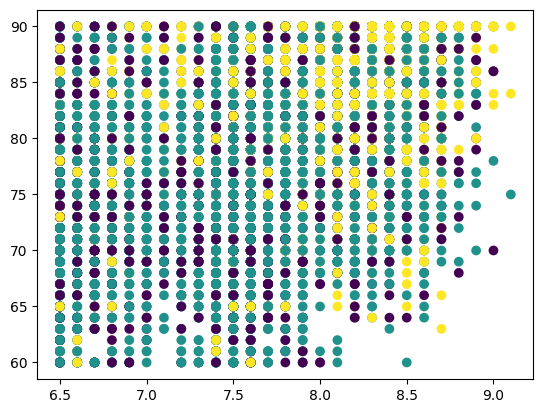

In [30]:
plt.scatter(df['CGPA'], df['AptitudeTestScore'], c=df['Internships'])

In [32]:
X = df.iloc[:,0:2]
Y = df.iloc[:,-1]

1. EXTRACT INPUT AND OUTPUT COLS
COLOMN KO DEVIDE KARNE KA RULE HAI

In [33]:
X

,CGPA,Internships
0,7.5,1
1,8.9,0
2,7.3,1
3,7.5,1
4,8.3,1
...,...,...
9995,7.5,1
9996,7.4,0
9997,8.4,1
9998,8.9,0


In [34]:
Y

,PlacementStatus
0,NotPlaced
1,Placed
2,NotPlaced
3,Placed
4,Placed
...,...
9995,NotPlaced
9996,Placed
9997,Placed
9998,Placed


3. TRAIN TEST SPLIT

In [37]:
from sklearn.model_selection import train_test_split
X_trains,X_test, Y_trains, Y_test = train_test_split(X,Y,test_size=0.1)

In [38]:
X_trains

,CGPA,Internships
3164,6.8,0
3441,8.0,1
6769,7.9,1
3102,7.6,1
7026,6.5,1
...,...,...
392,8.9,0
7299,8.4,2
4802,7.8,1
8692,8.3,0


In [39]:
X_test

,CGPA,Internships
4956,7.4,1
9071,6.9,1
7152,6.7,1
8762,8.1,1
262,8.1,0
...,...,...
4731,7.8,2
893,6.5,0
8470,7.6,1
5196,8.3,1


In [40]:
Y_test


,PlacementStatus
4956,NotPlaced
9071,NotPlaced
7152,NotPlaced
8762,NotPlaced
262,Placed
...,...
4731,NotPlaced
893,Placed
8470,Placed
5196,Placed


In [41]:
Y_trains

,PlacementStatus
3164,Placed
3441,NotPlaced
6769,NotPlaced
3102,NotPlaced
7026,NotPlaced
...,...
392,Placed
7299,Placed
4802,Placed
8692,Placed


In [42]:
from sklearn.preprocessing import StandardScaler

In [43]:
scaler = StandardScaler()

In [44]:
X_trains = scaler.fit_transform(X_trains)

In [45]:
X_trains

array([[-1.40308484, -1.57768191],
       [ 0.46854989, -0.07782586],
       [ 0.31258033, -0.07782586],
       ...,
       [ 0.15661077, -0.07782586],
       [ 0.93645857, -1.57768191],
       [ 0.78048901,  1.42203018]])

In [47]:
X_test = scaler.fit_transform(X_test)

In [48]:
X_test

array([[-0.45020542, -0.03801979],
       [-1.24337918, -0.03801979],
       [-1.56064868, -0.03801979],
       ...,
       [-0.13293592, -0.03801979],
       [ 0.97750733, -0.03801979],
       [-0.29157067, -0.03801979]])

train the model

In [49]:
from sklearn.linear_model import LogisticRegression

In [50]:
clf = LogisticRegression()

In [55]:
clf.fit(X_trains,Y_trains)

LogisticRegression()

In [56]:
clf.predict(X_test)

array(['NotPlaced', 'NotPlaced', 'NotPlaced', 'Placed', 'NotPlaced',
       'Placed', 'Placed', 'NotPlaced', 'Placed', 'NotPlaced',
       'NotPlaced', 'NotPlaced', 'NotPlaced', 'Placed', 'Placed',
       'Placed', 'NotPlaced', 'NotPlaced', 'NotPlaced', 'NotPlaced',
       'NotPlaced', 'NotPlaced', 'NotPlaced', 'NotPlaced', 'NotPlaced',
       'Placed', 'Placed', 'Placed', 'NotPlaced', 'Placed', 'NotPlaced',
       'NotPlaced', 'NotPlaced', 'Placed', 'NotPlaced', 'NotPlaced',
       'Placed', 'Placed', 'Placed', 'Placed', 'Placed', 'NotPlaced',
       'NotPlaced', 'NotPlaced', 'Placed', 'Placed', 'NotPlaced',
       'NotPlaced', 'NotPlaced', 'Placed', 'Placed', 'Placed',
       'NotPlaced', 'NotPlaced', 'Placed', 'NotPlaced', 'NotPlaced',
       'NotPlaced', 'NotPlaced', 'NotPlaced', 'NotPlaced', 'Placed',
       'NotPlaced', 'NotPlaced', 'NotPlaced', 'NotPlaced', 'NotPlaced',
       'Placed', 'NotPlaced', 'NotPlaced', 'NotPlaced', 'Placed',
       'Placed', 'NotPlaced', 'NotPlaced', '

In [58]:
Y_test

,PlacementStatus
4956,NotPlaced
9071,NotPlaced
7152,NotPlaced
8762,NotPlaced
262,Placed
...,...
4731,NotPlaced
893,Placed
8470,Placed
5196,Placed


In [62]:
from sklearn.metrics import accuracy_score

In [63]:
Y_pred = clf.predict(X_test)

In [64]:
accuracy_score(Y_test,Y_pred)

0.751

In [81]:
import pickle

kisi bhi object ko file me con vert kar deta hai

In [82]:
pickle.dump(clf,open('model.pkl','wb'))